# Data Cleaning & Exploratory Data Analysis (EDA)

## Data Cleaning

### Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Step 2: Load the dataset

In [3]:
df = pd.read_csv("dirty_sales_data.csv")
df.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32,USD 858,########,10%
1,1/30/2024,north,Tablet,Electronics,72,$833.83,########,15 percent
2,2/13/2024,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,4/28/2024,West,Laptop,gadget,thirty,$733.46,########,0.1
4,2/18/2024,EAST,Phone,ELEC,47,USD 373,"40,920",0.1
5,April 03 2024,South,laptop,Gadgets,twenty,670.28,3103,8 percent
6,1/28/2024,north,tablet,electronics,thirty,758.58,"37,789",8 percent
7,March 15 2024,West,Tablet,Gadgets,47,$241.65,"11,484",12%
8,January 09 2024,West,Phone,gadget,thirty,USD 796,"18,486",8 percent
9,2/7/2024,West,laptop,Gadgets,thirty,$996.92,"20,558",0.08


### Step 3: Check for missing values and info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               200 non-null    str  
 1   Region             200 non-null    str  
 2   Product            200 non-null    str  
 3   Category           200 non-null    str  
 4   Units Sold         196 non-null    str  
 5   Unit Price         200 non-null    str  
 6   Total Sales        197 non-null    str  
 7   Profit Margin (%)  200 non-null    str  
dtypes: str(8)
memory usage: 22.7 KB


### Step 3.1: Handle missing values (NaN)

In [5]:
df.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           4
Unit Price           0
Total Sales          3
Profit Margin (%)    0
dtype: int64

#### Step 3.1.1: Ensure numeric columns are numeric before filling NaN

In [6]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors="coerce")

df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors="coerce")

#### Step 3.1.2: Fill missing numeric values with the column mean

In [7]:
df["Units Sold"] = df["Units Sold"].fillna(df["Units Sold"].mean())

df["Total Sales"] = df["Total Sales"].fillna(df["Total Sales"].mean())

df["Units Sold"] = df["Units Sold"].astype(int)

### Step 4: Clean column names (remove leading/trailing spaces)

In [8]:
df.columns = df.columns.str.strip()

### Step 5: Fix date formats (convert inconsistent text into date format)

In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

### Step 6: Standardise text columns (make names consistent)

In [10]:
for col in ["Region", "Product", "Category"]:
    df[col] = df[col].str.strip().str.title()

### Step 7: Standardise "Category" names (make names consistent)

In [11]:
mapping = {"Elec": "Electronics", "Gadget": "Gadgets"}

df["Category"] = df["Category"].replace(mapping)

### Step 8: Convert "Units Sold" values to numeric (convert words like 'twenty' into NaN)

In [12]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors="coerce")

### Step 9: Clean currency columns (Unit Price, Total Sales)

In [13]:
for col in ["Unit Price", "Total Sales"]:
    df[col] = df[col].astype(str)
    df[col] = (df[col]
                .str.replace("[$, USD]", "", regex=True)
                .str.strip()
                )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Step 10: Fix Profit Margin (%)

#### Contains values like 10%, 0.10, or 10 percent (need to make them consistent)

In [14]:
df["Profit Margin (%)"] = (df["Profit Margin (%)"]
                           .astype(str)
                           .str.replace("%", "", regex=True)
                           .str.replace("percent", "", regex=True)
                           .astype(float))

df["Profit Margin (%)"] = np.where(
                                    df["Profit Margin (%)"] < 1, 
                                    df["Profit Margin (%)"] * 100, 
                                    df["Profit Margin (%)"])

### Step 11: Drop rows with missing key data (clean final dataset)

In [15]:
df_cleaned = df.dropna(subset=["Date", "Region", "Total Sales"])

### Step 12: Check cleaned results

In [16]:
df_cleaned.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32,858.00,26096.323077,10.0
5,2024-04-03,South,Laptop,Gadgets,52,670.28,3103.000000,8.0
7,2024-03-15,West,Tablet,Gadgets,47,241.65,26096.323077,12.0
8,2024-01-09,West,Phone,Gadgets,52,796.00,26096.323077,8.0
10,2024-01-26,South,Desktop,Electronics,52,100.76,26096.323077,8.0
12,2024-04-06,North,Tablet,Electronics,52,548.00,26096.323077,8.0
14,2024-03-03,South,Tablet,Electronics,52,348.60,7352.000000,8.0
18,2024-03-03,South,Laptop,Electronics,28,655.07,26096.323077,8.0
23,2024-01-20,East,Desktop,Gadgets,52,803.81,26096.323077,15.0
25,2024-04-25,South,Tablet,Electronics,52,540.16,26096.323077,10.0


### Step 13: Save cleaned data as a CSV file

In [ ]:
df_cleaned.to_csv("cleaned_sales_data.csv")

## Exploratory Data Analysis (EDA)

### 1: Total Sales by Region

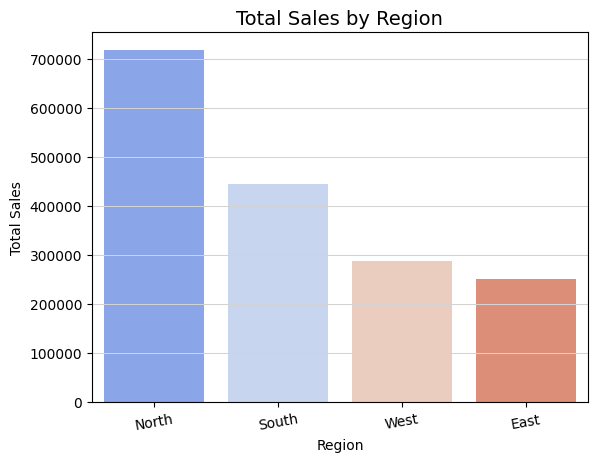

In [18]:
plt.Figure(figsize=(1, 1))
sns.barplot(data=df_cleaned, x="Region", y="Total Sales", estimator=sum, palette="coolwarm", errorbar=None)
#sns.despine(top=True)
plt.grid(axis="y", linestyle="solid", linewidth=0.75, color="lightgray")
plt.title("Total Sales by Region", fontsize=14)
plt.xticks(rotation=10)
plt.show()

### 2. Total Sales by Product

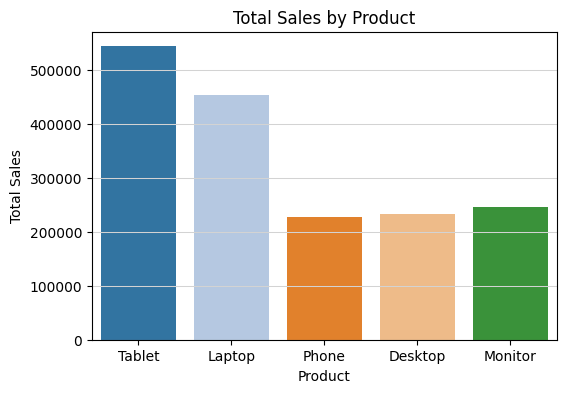

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_cleaned, x="Product", y="Total Sales", estimator=sum, palette="tab20", errorbar=None)
plt.grid(axis="y", linestyle="solid", linewidth=0.75, color="lightgray")
plt.title("Total Sales by Product")
plt.show()

### 3: Sales by Category

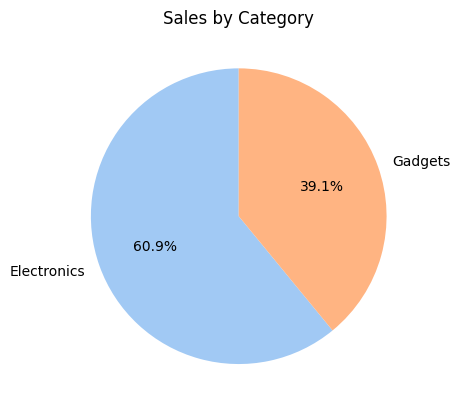

In [20]:
plt.Figure(figsize=(1, 1))
category_sales = df_cleaned.groupby("Category")["Total Sales"].sum()
category_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sales by Category")
plt.ylabel("")
plt.show()

### 4. Monthly Sales Trend

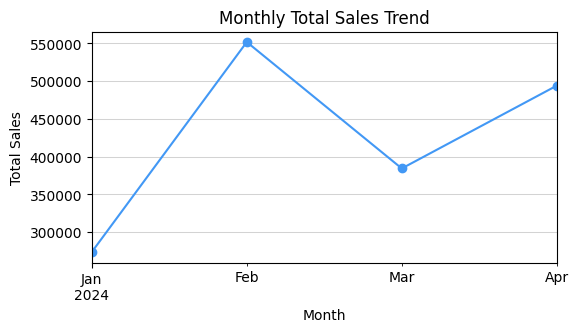

In [21]:
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], dayfirst=True)
df_cleaned["Month"] = df_cleaned["Date"].dt.to_period("M")
monthly = df_cleaned.groupby("Month")["Total Sales"].sum()

plt.figure(figsize=(6,3))
monthly.plot(marker="o", color="#4298f5")
plt.grid(axis="y", linestyle="solid", linewidth=0.75, color="lightgray")
plt.title("Monthly Total Sales Trend")
plt.ylabel("Total Sales")
plt.show()

### 5: Sales Trend Over Time

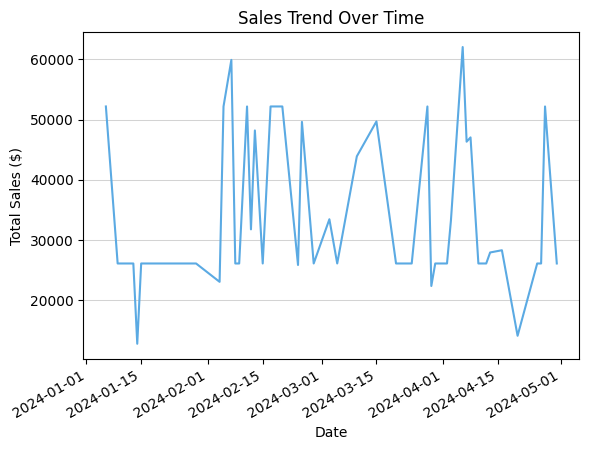

In [22]:
plt.Figure(figsize=(1,1))
df_cleaned.groupby("Date")["Total Sales"].sum().plot(kind="line", color="#5baae3")
plt.grid(axis="y", linestyle="solid", linewidth=0.75, color="lightgray")
plt.title("Sales Trend Over Time")
plt.ylabel("Total Sales ($)")
plt.show()

### 6. Profit Margin Distribution

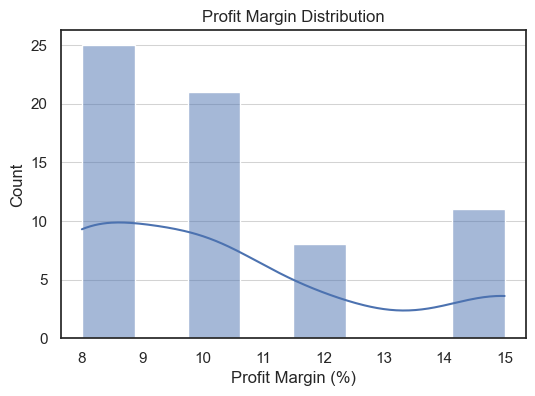

In [23]:
sns.set(style="white", palette="deep") 
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned["Profit Margin (%)"], bins=8, kde=True)
plt.grid(axis="y", linestyle="solid", linewidth=0.75, color="lightgray")
plt.title("Profit Margin Distribution")
plt.show()

### 7. Units Sold vs Total Sales

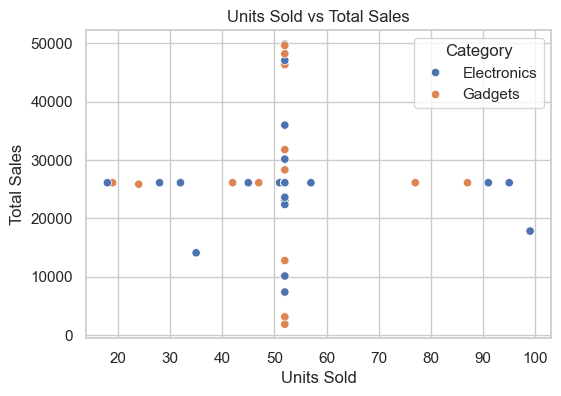

In [24]:
sns.set(style="whitegrid", palette="deep")
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_cleaned, x="Units Sold", y="Total Sales", hue="Category")
plt.title("Units Sold vs Total Sales")
plt.show()